# Modèle de score (Poisson)

Au lieu de prédire directement une classe, on prédit le **nombre de buts attendu** de chaque équipe (λ), puis on en
**déduit** la distribution des scores → probabilités victoire / **nul** / défaite (et bonus : plus/moins de 2.5 buts,
les deux équipes marquent).

**Pourquoi c'est mieux pour le nul** : le nul n'est plus une classe à part à « attraper », il **émerge** quand
λ_domicile ≈ λ_extérieur. Et **attaque / défense reprennent du sens** : les buts d'une équipe dépendent de **son
attaque** contre **la défense adverse** — une confrontation, pas des doublons de l'overall.

λ_équipe = exp( intercept + home_adv·domicile + a·attaque_équipe + d·défense_adverse )

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import poisson
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             cohen_kappa_score, log_loss, classification_report, confusion_matrix)

RANDOM_STATE=42; CLASSES=["away_win","draw","home_win"]; MAXG=10
COLOR, INK, INK_SOFT = "#2a78d6", "#0b0b0b", "#52514e"
BLUES=LinearSegmentedColormap.from_list("b",["#f0efec","#8ec5f4","#3987e5","#184f95"])
plt.rcParams.update({"figure.facecolor":"#fcfcfb","axes.facecolor":"#fcfcfb","axes.edgecolor":"#c9c8c3",
    "axes.labelcolor":INK_SOFT,"axes.spines.top":False,"axes.spines.right":False,"axes.titlelocation":"left",
    "text.color":INK,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"grid.color":"#e6e5e0","font.size":10})

df = pd.read_csv("data/match_outcome_team_ratings.csv", parse_dates=["match_date"]).sort_values(["match_date","match_id"]).reset_index(drop=True)
cut = int(0.8*len(df)); train, test = df.iloc[:cut], df.iloc[cut:]
print("train:", len(train), "| test:", len(test), "|", test["match_date"].min().date(), "->", test["match_date"].max().date())

def long_format(d):
    # 2 lignes par match : point de vue de l'équipe qui attaque
    h = pd.DataFrame({"goals": d["home_score"], "team_attack": d["home_attack"], "opp_defence": d["away_defence"], "is_home": 1})
    a = pd.DataFrame({"goals": d["away_score"], "team_attack": d["away_attack"], "opp_defence": d["home_defence"], "is_home": 0})
    return pd.concat([h, a], ignore_index=True)

long_train = long_format(train)
print("\nlong train:", long_train.shape, "| buts moyens/équipe:", round(long_train['goals'].mean(),2))

train: 698 | test: 175 | 2026-03-18 -> 2026-05-24

long train: (1396, 4) | buts moyens/équipe: 1.56


## 1. Ajuster le Poisson

Régression de Poisson : `buts ~ attaque_équipe + défense_adverse + domicile`. On attend un coef **+** pour
l'attaque, **−** pour la défense adverse (adversaire mieux défendu → moins de buts), **+** pour le domicile.

In [2]:
FEATS = ["team_attack", "opp_defence", "is_home"]
pois = make_pipeline(StandardScaler(), PoissonRegressor(alpha=1e-3, max_iter=500)).fit(long_train[FEATS], long_train["goals"])

coefs = pd.Series(pois.named_steps["poissonregressor"].coef_, index=FEATS)
print("coefficients (sur features standardisées) :")
print(coefs.round(3).to_string())
print("\ninterprétation : attaque + / défense adverse - / domicile + = conforme au foot")

coefficients (sur features standardisées) :
team_attack    0.231
opp_defence   -0.176
is_home        0.131

interprétation : attaque + / défense adverse - / domicile + = conforme au foot


## 2. Des λ à la distribution des scores

Pour un match : λ_dom (attaque dom vs défense ext, à domicile) et λ_ext. En supposant deux Poisson indépendants,
`P(score dom=i, ext=j) = Poisson(i;λ_dom)·Poisson(j;λ_ext)`. On somme la matrice pour obtenir victoire / nul /
défaite — et au passage plus/moins de 2.5 buts et « les deux marquent ».

In [3]:
def lambdas(d):
    lam_h = pois.predict(pd.DataFrame({"team_attack": d["home_attack"], "opp_defence": d["away_defence"], "is_home": 1}))
    lam_a = pois.predict(pd.DataFrame({"team_attack": d["away_attack"], "opp_defence": d["home_defence"], "is_home": 0}))
    return lam_h, lam_a

def score_matrix(lh, la):
    i = np.arange(MAXG+1)
    return np.outer(poisson.pmf(i, lh), poisson.pmf(i, la))   # M[i,j] = P(dom=i, ext=j)

lam_h, lam_a = lambdas(test)
proba, over25, btts = [], [], []
for lh, la in zip(lam_h, lam_a):
    M = score_matrix(lh, la)
    p_home = np.tril(M, -1).sum(); p_draw = np.trace(M); p_away = np.triu(M, 1).sum()
    proba.append([p_away, p_draw, p_home])                    # ordre CLASSES
    over25.append(1 - M[np.add.outer(np.arange(MAXG+1), np.arange(MAXG+1)) <= 2].sum())
    btts.append((1 - poisson.pmf(0, lh)) * (1 - poisson.pmf(0, la)))
proba = np.array(proba)
proba = proba / proba.sum(axis=1, keepdims=True)   # normalise (troncature à 10 buts)
y_pred = np.array(CLASSES)[proba.argmax(1)]
y_test = test["result"].values
print("λ moyen — domicile:", round(lam_h.mean(),2), "| extérieur:", round(lam_a.mean(),2))

λ moyen — domicile: 1.76 | extérieur: 1.35


## 3. Évaluation (mêmes métriques que le classifieur direct)

=== Poisson vs dummy (test) ===


,accuracy,balanced_acc,macro_F1,kappa,log_loss
modèle,,,,,
dummy — priors,0.474,0.333,0.214,0.000,1.040
Poisson (score),0.520,0.393,0.341,0.126,1.004


=== détail par classe (Poisson) ===
              precision    recall  f1-score   support

    away_win      0.552     0.276     0.368        58
        draw      0.000     0.000     0.000        34
    home_win      0.514     0.904     0.655        83

    accuracy                          0.520       175
   macro avg      0.355     0.393     0.341       175
weighted avg      0.426     0.520     0.433       175



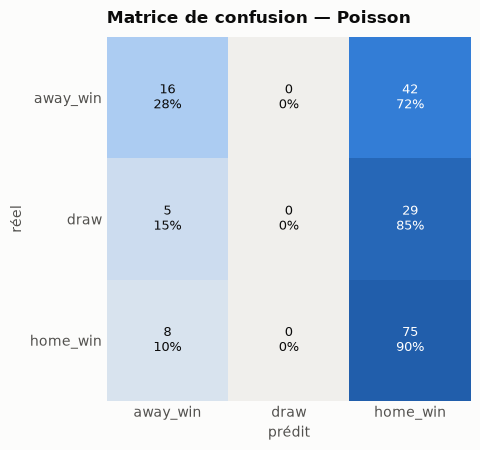

In [4]:
def metrics(name, yt, yp, pr):
    return {"modèle": name, "accuracy": accuracy_score(yt,yp), "balanced_acc": balanced_accuracy_score(yt,yp),
            "macro_F1": f1_score(yt,yp,average="macro",zero_division=0), "kappa": cohen_kappa_score(yt,yp),
            "log_loss": log_loss(yt, pr, labels=CLASSES)}

dummy = DummyClassifier(strategy="prior").fit(train[["home_overall"]], train["result"])
d_pred = dummy.predict(test[["home_overall"]])
d_proba = dummy.predict_proba(test[["home_overall"]])[:, [list(dummy.classes_).index(c) for c in CLASSES]]

table = pd.DataFrame([
    metrics("dummy — priors", y_test, d_pred, d_proba),
    metrics("Poisson (score)", y_test, y_pred, proba),
]).set_index("modèle").round(3)
print("=== Poisson vs dummy (test) ===")
display(table)
print("=== détail par classe (Poisson) ===")
print(classification_report(y_test, y_pred, labels=CLASSES, digits=3, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=CLASSES); cmn = cm/cm.sum(1,keepdims=True)
fig, ax = plt.subplots(figsize=(5.2,4.6))
ax.imshow(cmn, cmap=BLUES, vmin=0, vmax=1)
ax.set_xticks(range(3),CLASSES); ax.set_yticks(range(3),CLASSES); ax.set_xlabel("prédit"); ax.set_ylabel("réel"); ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
for i in range(3):
    for j in range(3): ax.text(j,i,f"{cm[i,j]}\n{cmn[i,j]:.0%}",ha="center",va="center",fontsize=9,color="#fff" if cmn[i,j]>0.5 else INK)
ax.set_title("Matrice de confusion — Poisson", fontweight="bold", pad=10); fig.tight_layout(); plt.show()

## 4. Exemples : ce que le modèle « voit »

Pour chaque match : λ des deux équipes, probas 1X2, score le plus probable, et le vrai résultat.

In [5]:
ex = test.head(10).copy().reset_index(drop=True)
ex["lambda_dom"] = lam_h[:10].round(2); ex["lambda_ext"] = lam_a[:10].round(2)
ex["P_dom"] = proba[:10,2].round(2); ex["P_nul"] = proba[:10,1].round(2); ex["P_ext"] = proba[:10,0].round(2)
ex["over_2.5"] = np.round(over25[:10],2); ex["BTTS"] = np.round(btts[:10],2)
ex["score_reel"] = ex["home_score"].astype(str)+"-"+ex["away_score"].astype(str)
cols = ["home_sofifa_team_name","away_sofifa_team_name","lambda_dom","lambda_ext","P_dom","P_nul","P_ext","over_2.5","BTTS","score_reel","result"]
display(ex[cols])

,home_sofifa_team_name,away_sofifa_team_name,lambda_dom,lambda_ext,P_dom,P_nul,P_ext,over_2.5,BTTS,score_reel,result
0,FC Barcelona,Newcastle United,2.09,1.24,0.57,0.21,0.22,0.65,0.62,7-2,home_win
1,Tottenham Hotspur,Atlético Madrid,1.47,1.48,0.38,0.25,0.38,0.57,0.59,3-2,home_win
2,Shakhtar Donetsk,Lech Poznań,1.66,1.19,0.48,0.24,0.27,0.54,0.56,1-2,away_win
3,Sparta Praha,AZ Alkmaar,1.83,1.35,0.49,0.23,0.28,0.62,0.62,0-4,away_win
4,Raków Częstochowa,Fiorentina,1.36,1.83,0.29,0.23,0.48,0.62,0.62,1-2,away_win
5,Real Betis Balompié,Panathinaikos FC,1.93,1.06,0.58,0.22,0.20,0.57,0.56,4-0,home_win
6,SC Freiburg,KRC Genk,1.36,1.05,0.44,0.27,0.29,0.43,0.48,5-1,home_win
7,FC Porto,VfB Stuttgart,1.85,1.38,0.49,0.23,0.29,0.63,0.63,2-0,home_win
8,FC Midtjylland,Nottingham Forest,1.16,1.76,0.25,0.24,0.51,0.56,0.57,1-5,away_win
9,Roma,Bologna,1.85,1.07,0.56,0.23,0.22,0.56,0.56,3-4,away_win


## Conclusion

- Le Poisson **prédit le nul naturellement** (sans `class_weight`) : il émerge quand λ_dom ≈ λ_ext. À comparer au
  classifieur direct qui devait être forcé.
- **Bonus gratuits** : plus/moins de 2.5 buts, « les deux marquent », score exact — un seul modèle, plusieurs sorties
  de type marché de paris.
- **Attaque/défense servent ici** (confrontation), là où elles étaient redondantes dans le 1X2 agrégé.
- Limite : l'hypothèse d'indépendance des deux Poisson sous-estime un peu les nuls (le vrai modèle **Dixon-Coles**
  ajoute une correction pour les petits scores 0-0/1-1) — amélioration possible si besoin.